## Úloha a dataset

Budeme predikovat průměrný počet dní strávených volnočasovými aktivitami za rok v Japonsku na základě demografických příznaků (věk, pohlaví, zdraví, rodinný stav a ekonomická aktivita). Jedná se o supervizovanou regresi, ve které se snažíme pochopit, jak demografické faktory ovlivňují trávení volného času.

Zdroj - Survey on Time Use and Leisure Activities https://www.e-stat.go.jp/en

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection   import (train_test_split,
                                       RandomizedSearchCV)
from sklearn.linear_model      import  LinearRegression
from sklearn.ensemble          import  RandomForestRegressor
from sklearn.metrics           import (mean_absolute_error,
                                       mean_squared_error,
                                       r2_score)
from sklearn.feature_selection import mutual_info_regression

Dataset je ve zdroji rozdělen do několika samostatných CSV souborů, pro další práci je budeme muset spojit do jednoho datového rámce.

In [2]:
RANDOM_STATE = 51

df = pd.read_csv('FEH_01.csv')

df_tmp = pd.read_csv('FEH_02.csv')
df = pd.concat([df, df_tmp])

df_tmp = pd.read_csv('FEH_03.csv')
df = pd.concat([df, df_tmp])

df_tmp = pd.read_csv('FEH_04.csv')
df = pd.concat([df, df_tmp])

df_tmp = pd.read_csv('FEH_05.csv')
df = pd.concat([df, df_tmp])

### Popis dat

Některé proměnné v datasetu mají konstantní hodnotu (např. 'Time' nebo 'unit'). Tyto proměnné nemají žádnou informační hodnotu pro modelování ani analýzu, proto je odstraníme.

In [3]:
display(df[['tab_code', 'Tabulated variable', 'time_code', 'Time', 'unit']].sample(3))
df.drop(['tab_code', 'Tabulated variable', 'time_code', 'Time', 'unit'], axis=1, inplace=True)

,tab_code,Tabulated variable,time_code,Time,unit
15248,202114A13,Average days for participation per year,2021000000,2021,days
46573,202114A13,Average days for participation per year,2021000000,2021,days
45956,202114A13,Average days for participation per year,2021000000,2021,days


In [4]:
df.sample(2)

,cat01_code,Sex,cat02_code,Marital status,cat03_code,Usual economic activity,cat04_code,Usual state of health,cat05_code,Age,cat06_code,Kind of hobbies and amusements,value
18745,0,0_Both sexes,0,0_Total,13,13_Working besides mainly attending school,5,5_Poor,01,01_15 to 19 years old,12,"12_""Karaoke""",...
64425,1,1_Male,3,3_Widowed or divorced,23,23_Other,1,1_Excellent,10,10_60 to 64 years old,8,"08_Listening to music by CDs, SPs, etc.",...


Budeme pracovat s datasetem 'Průzkum o využití času a volnočasových aktivitách', který má 401 472 záznamů a 13 příznaků.
Jedná se však o agregovaná data, každý řádek je kombinací demografických charakteristik, ke kterým je přiřazena průměrná hodnota. Nejedná se o individuální respondenty, ale o statistické skupiny obyvatel.

Příznaky:
- **Sex** 
  - Pohlaví (Total, Male, Female)
  - Kategorický (Nominální)
- **Marital status**
  - Rodinný stav (Total, Married, Never married, atd.)
  - Kategorický (Nominální)
- **Usual economic activity** 
  - Ekonomická činnost (Working, Not Working, atd.)
  - Kategorický (Nominální)
- **Usual state of health** 
  - Pocit zdraví (Excellent až Poor)
  - Kategorický (Ordinální)
- **Age** 
  - Věk (v pětiletých intervalech, 15 to 19 years old, atd.)
  - Kategorický (Ordinální)
- **Kind of hobbies and amusements**
  - Typ volnočasové aktivity
  - 34 kategorií (Nominální) (sport, četba, atd.) 
- **value** 
  - Cílová proměnná
  - Průměrný počet dní strávených volnočasovými aktivitami během roku
  - Numerický (Spojitý)
- **cat0X_code**
  - Číselné kódování jednotlivých příznaků

## Předzpracování dat

### Přejmenování
Pro zlepšení čitelnosti sloupce přejmenujeme na kratší názvy.

In [5]:
df.rename(columns={"cat01_code" : "sex_code",
                   "cat02_code" : "family_code",
                   "cat03_code" : "work_code",                   
                   "cat04_code" : "health_code",
                   "cat05_code" : "age_code",
                   "cat06_code" : "hobbies_code",

                   "Marital status" :                 "Family",
                   "Usual state of health" :          "Health",
                   "Usual economic activity" :        "Work",
                   "Kind of hobbies and amusements" : "Hobbies"}, inplace=True)

df.head(1)

,sex_code,Sex,family_code,Family,work_code,Work,health_code,Health,age_code,Age,hobbies_code,Hobbies,value
0,0,0_Both sexes,0,0_Total,0,0_Total,0,0_Total,00,00_Total,1,01_Watching sports and matches (excluding TV P...,32.9


### Zkrácení hodnot
Nekódované kategorie obsahují zbytečné kódování a 'Hobbies' jsou trochu moc deskriptivní. Proto je pro zpřehlednění trochu zkrátíme..

In [6]:
df['Sex']     = df['Sex'].str.replace(r"^\d+_", "", regex=True)
df['Family']  = df['Family'].str.replace(r"^\d+_", "", regex=True)
df['Work']    = df['Work'].str.replace(r"^\d+_", "", regex=True)
df['Health']  = df['Health'].str.replace(r"^\d+_", "", regex=True)
df['Age']     = df['Age'].str.replace(r"^\d+_", "", regex=True)
df['Age']     = df['Age'].str.replace(r" years old", "", regex=True)
df['Hobbies'] = df['Hobbies'].str.replace(r"^\d+_", "", regex=True)

df['Hobbies'] = df['Hobbies'].str.replace("\\(.*\\)", "", regex=True)
df['Hobbies'] = df['Hobbies'].apply(lambda x: x[:30] + '...' if len(x) > 30 else x)

df.head(1)

,sex_code,Sex,family_code,Family,work_code,Work,health_code,Health,age_code,Age,hobbies_code,Hobbies,value
0,0,Both sexes,0,Total,0,Total,0,Total,00,Total,1,Watching sports and matches,32.9


### Redundantní řádky

Dataset obsahuje kromě specifických kategorií (např. 'Female', 'Male') také agregované úrovně ('Total', 'Regrouped'). Tyto záznamy nepředstavují nezávislá pozorování, ale souhrnné statistiky nad jemnějšími kategoriemi. Mohly by zkreslit vztahy mezi příznaky, míchat hierarchické úrovně, přidávat redundanci, nebo mohou být matoucí.rie.

In [7]:
display(df[(df['family_code'] == 0) & (df['work_code'] == 0) & (df['health_code'] == 0) & (df['age_code'] == '00') & (df['hobbies_code'] == 1)])

,sex_code,Sex,family_code,Family,work_code,Work,health_code,Health,age_code,Age,hobbies_code,Hobbies,value
0,0,Both sexes,0,Total,0,Total,0,Total,00,Total,1,Watching sports and matches,32.9
33824,1,Male,0,Total,0,Total,0,Total,00,Total,1,Watching sports and matches,37.5
67648,2,Female,0,Total,0,Total,0,Total,00,Total,1,Watching sports and matches,25.6


V ukázce (chceme porovnat pohlaví, všechny ostatní příznaky jsou stejné) vidíme, že 'Total' není jen jednoduchý průměr detailů. Může se jednat o vážený průměr (poměr žen a mužů) nebo spočten jinak. Proto jej odstraníme a zachováme pouze nejmenší kategorie.

In [8]:
df_len = df.shape[0]
print(f"Původní počet řádků:      {df_len}")

df = df[( df['sex_code']    != 0) & 
        ( df['family_code'] != 0) & 
        ( df['work_code']   != 0) & 
        ( df['health_code'] != 0) & 
        ( df['age_code']    != '00') &
        (~df['age_code'].str.startswith('R'))]

print(f"Počet řádků po vyčištění: {df.shape[0]} ({df.shape[0] / df_len * 100:.2f}% zbylých)")

Původní počet řádků:      401472
Počet řádků po vyčištění: 99960 (24.90% zbylých)


## Chybějící hodnoty

Protože se jedná o agregovaný dataset, chybějící hodnoty se vyskytují především u cílové proměnné 'value'. Ty jsou reprezentovány pomocí '-' a '...', které neodpovídají nulové aktivitě, ale absenci nebo nespolehlivému měření.

In [9]:
print(f"Původní počet řádků:       {df_len}")
print(f"Počet řádků po vyčištění:   {df.shape[0]} ({df.shape[0] / df_len * 100:.2f}% zbylých)")

df['value'] = df['value'].replace(['-', '...'], np.nan)

print(f"Počet řádků po chybějících: {df['value'].notnull().sum()} ( {df['value'].notnull().sum() / df_len * 100:.2f}% zbylých)")

Původní počet řádků:       401472
Počet řádků po vyčištění:   99960 (24.90% zbylých)
Počet řádků po chybějících: 39400 ( 9.81% zbylých)


Po odstranění agregovaných kategorií a záznamů s chybějící cílovou proměnnou došlo k výraznému snížení počtu řádků. Zůstalo nám přibližně 10 % původních dat, což poukazuje na to, že dataset obsahoval velké množství hierarchicky agregovaných a neúplných statistik. Výsledný dataset by teď měl obsahovat jen jednoznačně definované demografické charakteristiky a známou cílovou proměnnou.

Teď si vizualizujeme chybějící hodnoty a uvidíme, jestli by se daly třeba doplnit.

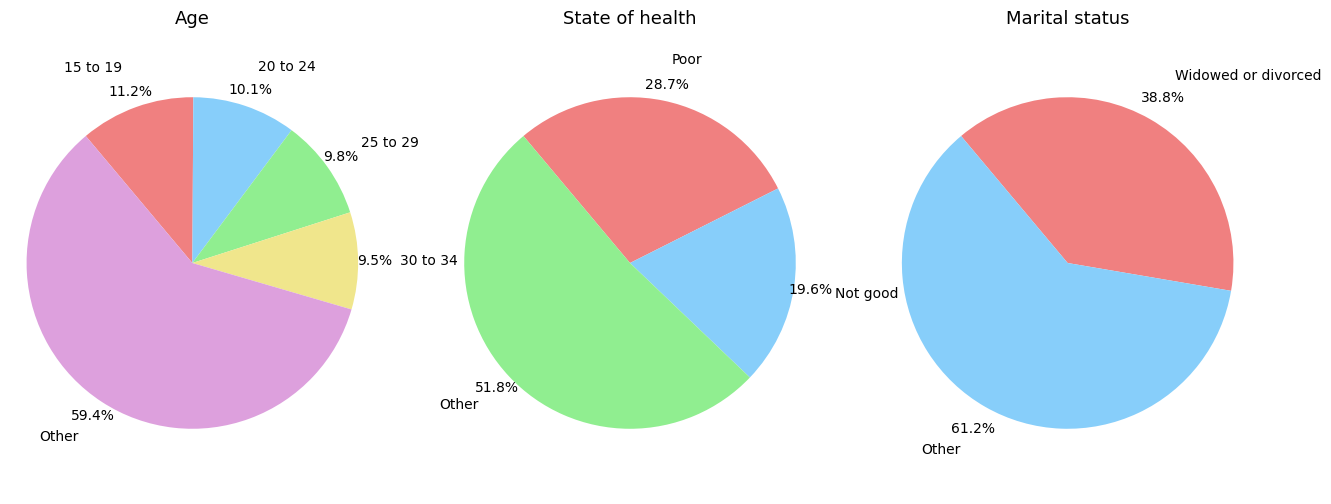

In [10]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize=(16,6))

colors  = ['lightcoral', 'lightskyblue', 'lightgreen', 'khaki', 'plum', 'tan']
df_miss = df[df['value'].isna()].copy()

top_n = 4
miss_count = df_miss['Age'].value_counts()
top_counts = miss_count.nlargest(top_n)
other_sum  = miss_count.sum() - top_counts.sum()
top_counts['Other'] = other_sum

ax = axes[0]

ax.pie(top_counts.values, labels=top_counts.index, autopct='%1.1f%%', colors=colors,
       startangle=130, labeldistance=1.25, pctdistance=1.1, counterclock=False)

ax.set_title('Age', fontsize=13)
ax.axis('equal')

####################################################################################################################

top_n = 2
miss_count = df_miss['Health'].value_counts()
top_counts = miss_count.nlargest(top_n)
other_sum  = miss_count.sum() - top_counts.sum()
top_counts['Other'] = other_sum

ax = axes[1]

explode = [0.1 if i==0 else 0 for i in range(len(top_counts))]
ax.pie(top_counts.values, labels=top_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=130, labeldistance=1.25, pctdistance=1.1, counterclock=False)

ax.set_title('State of health', fontsize=13)
ax.axis('equal')

####################################################################################################################

top_n = 1
miss_count = df_miss['Family'].value_counts()
top_counts = miss_count.nlargest(top_n)
other_sum  = miss_count.sum() - top_counts.sum()
top_counts['Other'] = other_sum

ax = axes[2]

ax.pie(top_counts.values, labels=top_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=130, labeldistance=1.3, pctdistance=1.15, counterclock=False)

ax.set_title('Marital status', fontsize=13)
ax.axis('equal')

plt.show()

Tady máme ukázky příznaků a jejich nejčastějších chybějících hodnot. <br>
40% věk pod 35 let <br>
48% špatný zdravotní stav <br>
39% rozvedených nebo ovdovělých pro rodinné vztahy <br>

Hledat třeba rozvedené lidi ve věku 15 až 19 let se špatným zdravotním stavem nebude lehké, a proto není překvapivé, že takové hodnoty chybí.

Tudíž vidíme, že data nechybí náhodně, ale systematicky. Data proto nebudeme nijak doplňovat, protože by došlo k zavedení umělé informace a jejich zkreslení. Z toho důvodu chybějící hodnoty odstraníme.

In [11]:
df = df.dropna(subset=['value'])
df['value'] = pd.to_numeric(df['value'])

## Value a odlehlé hodnoty

Teď, když už nic nebudeme muset shazovat, se můžeme podívat na naši cílovou proměnnou a její odlehlé hodnoty. U ostatních příznaků nebudeme odlehlé hodnoty analyzovat, protože se jedná o kategoriální agregovaná data, u kterých se odlehlé hodnoty nevyskytují.

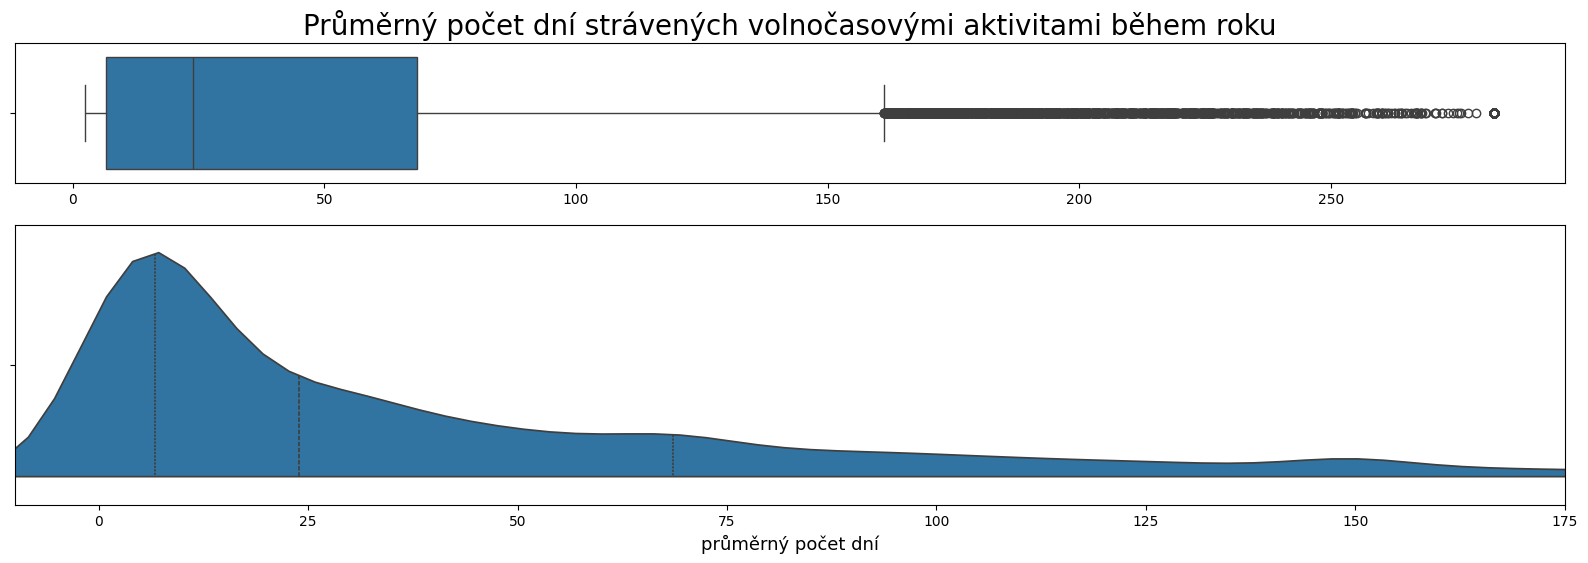

Štatistiky cílové proměnné: 
	Průměr:		 47.33 
	Median:		 23.90 
	Modus:		  2.5 
	N. modus:	  0.12 
	Min:		  2.5 
	Max:		282.50


In [12]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 6), gridspec_kw={'height_ratios': [1, 2]})

sns.boxplot(data=df, x='value', ax=axes[0])
axes[0].set_title('Průměrný počet dní strávených volnočasovými aktivitami během roku', fontsize=20)
axes[0].set_xlabel("")

sns.violinplot(data=df, x='value', ax=axes[1], split=True, inner="quarter")
axes[1].set_xlim(-10, 175)
axes[1].set_xlabel("průměrný počet dní", fontsize=13)

plt.show()

print(f"Štatistiky cílové proměnné:",
      f"\n\tPrůměr:\t\t",df['value'].mean().round(2),
      f"\n\tMedian:\t\t {df['value'].median():.2f}",
      f"\n\tModus:\t\t ",  df['value'].value_counts().round(2).index[0],
      f"\n\tN. modus:\t ", df['value'].value_counts(normalize=True).round(2).iloc[0],
      f"\n\tMin:\t\t ",    df['value'].min(),
      f"\n\tMax:\t\t{df['value'].max():.2f}")

Distribuce cílové proměnné je výrazně zešikmená, což je patrné z mediánu, který je přibližně poloviční oproti průměru. To poukazuje na přítomnost velmi vysokých hodnot v datasetu. Takto silná šikmost distribuce může negativně ovlivnit lineární modely.

Modus 2.5, který je zároveň minimální hodnotou, tvoří přibližně 12 % všech pozorování. To naznačuje, že většina volnočasových aktivit je vykonávána relativně zřídka (několik dní ročně), zatímco menší část aktivit je provozována velmi často, v některých případech téměř denně.

Boxplot ukazuje přítomnost odlehlých hodnot nad přibližně 160 dny ročně, přičemž některé dosahují až 282 dní. Tyto hodnoty však neodpovídají chybám v datech, ale reálně vysoké frekvenci určitých aktivit. Jejich odstranění by vedlo ke ztrátě informace o významné části populace, proto nebudou z datasetu odstraňovány.

## Analýza datasetu

Vzhledem k tomu, že dataset obsahuje agregovaná data, samotné četnosti kategorií vstupních proměnných neposkytují zásadní informace o chování jednotlivců. Proto se analýza zaměřuje především na vztah mezi vstupními příznaky a cílovou proměnnou, kde lze pozorovat smysluplné rozdíly v intenzitě volnočasových aktivit.

### Hobbies a values

'Hobbies' má největší počet kategorií a lze u ní očekávat největší rozmanitost chování, a tím pádem i potenciálně největší vliv na predikční model. Proto se na ni zaměříme podrobněji a porovnáme ji také s výskytem odlehlých hodnot cílové proměnné.

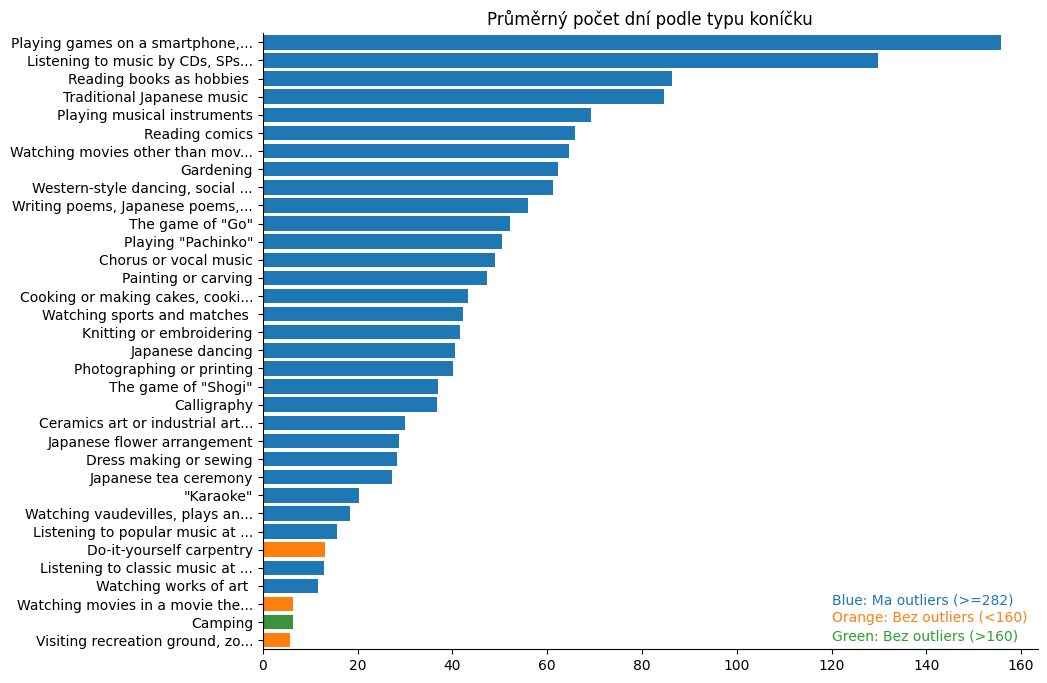

In [13]:
order = df.groupby('Hobbies')['value'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=df,
    x='value',
    y='Hobbies',
    order=order,
    errorbar=None,
    color='tab:green'
)

missing = df.loc[~df['Hobbies'].isin(df.loc[df['value'] > 160, 'Hobbies']), 'Hobbies'].unique()
highest = df[(df['value'] >= 282)]['Hobbies'].unique()

for bar, hobby in zip(ax.patches, order):
    if hobby in missing:
        bar.set_facecolor('tab:orange')
    if hobby in highest:
        bar.set_facecolor('tab:blue')

ax.text( 120, 31, 'Blue: Ma outliers (>=282)', color='tab:blue')
ax.text( 120, 32, 'Orange: Bez outliers (<160)', color='tab:orange')
ax.text( 120, 33, 'Green: Bez outliers (>160)', color='tab:green')

ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False) 

plt.title('Průměrný počet dní podle typu koníčku')
plt.show()

Tento graf zobrazuje vztah mezi typem volnočasové aktivity a průměrným počtem dní strávených touto činností. Kategorie jsou seřazeny sestupně podle průměru.<br>
Oranžově jsou zvýrazněny aktivity, u kterých se nevyskytují žádné odlehlé hodnoty (nad 160 dní). <br>
Modře jsou aktivity, které mají extrémní hodnoty (nad 282 dní). <br>
Zeleně nemají extrém, ale mají odlehlou hodnotu (nad 160, ale pod 282 dní).

Je vidět dominance domácích a digitálních aktivit, časté jsou aktivity jako hraní her a poslech hudby. Tyto činnosti jsou snadno dostupné a lze se jim věnovat denně.

Na druhé straně jsou aktivity jako kempování nebo navštěvování rekreačních zařízení, jako jsou kina, zoo, koncerty. Tyhle aktivity jsou časově a finančně náročné, což se odráží na jejich nízké frekvenci a absenci extrémů. Jsou to aktivity spíše příležitostného charakteru


Přestože jsou průměrné, mediánové i modusové hodnoty relativně nízké, většina aktivit má alespoň jednu skupinu, u které se vyskytují velmi vysoké hodnoty frekvence.

### Sex, Age, Family, Health, Work a value

Tyhle vstupní proměnné nemají tak velký počet proměnných a nepředpokládáme nějaké velké rozdíly mezi jejich hodnotami, a tudíž ne tak velký vliv na model jako 'Hobbies'. Ale pořád mohou obsahovat nějaké zajímavé poznatky pro nás.

In [14]:
def age_lower_bound(age):
    if age == '85 and over':
        return 85
    return int(age.split(' ')[0])

In [15]:
#order = df.groupby('Sex')['value'].mean().sort_values(ascending=False).index
#
#colors  = ['tab:blue', 'tab:pink']
##colors  = ['lightskyblue', 'lightcoral']
#
#plt.figure(figsize=(6, 4))
#ax = sns.barplot(data=df, x='value', y='Sex', order=order, errorbar=None, hue='Sex', legend=False, palette=colors)
#
#ax.set_xlabel('')
#ax.set_ylabel('')
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False) 
#ax.set_xlim(0, 65)
#
#plt.title('Průměrný počet dní podle pohlaví')
#plt.show()

In [16]:
#order = df.groupby('Family')['value'].mean().sort_values(ascending=False).index
#
#colors  = ['tab:green', 'tab:blue', 'tab:orange']
##colors  = ['lightgreen', 'lightskyblue', 'lightcoral']
#
#plt.figure(figsize=(6, 4))
#ax = sns.barplot(data=df, x='value', y='Family', order=order, errorbar=None, hue='Family', legend=False, palette=colors)
#
#ax.set_xlabel('')
#ax.set_ylabel('')
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False) 
#ax.set_xlim(0, 65)
#
#plt.title('Průměrný počet dní podle rodinného stavu')
#plt.show()

In [17]:
#order = df.groupby('Health')['value'].mean().sort_values(ascending=False).index
#
#colors  = ['tab:green', 'tab:blue', 'tab:grey', 'tab:orange', 'tab:red']
##colors  = ['lightgreen', 'lightskyblue', 'lightgray', 'lightsalmon', 'lightcoral']
#
#plt.figure(figsize=(6, 4))
#ax = sns.barplot(data=df, x='value', y='Health', order=order, errorbar=None, hue='Health', legend=False, palette=colors)
# 
#ax.set_xlabel('')
#ax.set_ylabel('')
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False) 
#ax.set_xlim(0, 65)
#
#plt.title('Průměrný počet dní podle zdraví')
#plt.show()

In [18]:
# order = df.groupby('Work')['value'].mean().sort_values(ascending=False).index
# 
# plt.figure(figsize=(6, 4))
# ax = sns.barplot(data=df, x='value', y='Work', order=order, errorbar=None, color='tab:blue')
# 
# threshold_idx = list(order).index("Attending school")
# 
# for i, bar in enumerate(ax.patches):
#     if i <= threshold_idx:
#         bar.set_facecolor('tab:blue')
#     else:
#         bar.set_facecolor('tab:green')
# 
#y_pos = list(order).index("Attending school")
#ax.axhline(y=y_pos + 0.5, color='black', linestyle='--', linewidth=1)
#
#ax.set_xlabel('')
#ax.set_ylabel('')
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False)
#ax.set_xlim(0, 65)
#
#plt.title('Průměrný počet dní podle ekonomické činnosti')
#plt.show()

In [19]:
#order = df.groupby('Age')['value'].mean().sort_values(ascending=False).index
#
#plt.figure(figsize=(6, 4))
#ax = sns.barplot(data=df, x='value', y='Age', order=order, errorbar=None)
#
#for bar, age in zip(ax.patches, order):
#    if age_lower_bound(age) >= 55:
#        bar.set_facecolor('tab:blue')
#    else:
#        bar.set_facecolor('tab:green')
#        
#y_pos = list(order).index("55 to 59")
#ax.axhline(y=y_pos + 0.45, color='black', linestyle='--', linewidth=1)
#
#ax.set_xlabel('')
#ax.set_ylabel('')
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False)
#ax.set_xlim(0, 65)
#
#plt.title('Průměrný počet dní podle věku')
#plt.show()

![images/valuex.png](images/valuex.png)

**Sex**<br>
Muži vykazují v průměru mírně vyšší počet dní strávených volnočasovými aktivitami než ženy. Rozdíl není dramatický, ale může naznačovat mírně vyšší dostupnost volného času nebo odlišné preference aktivit, případně souvislost s ekonomickou aktivitou. 

**Family**<br>
Rozdíly mezi jednotlivými skupinami podle rodinného stavu jsou relativně malé. Svobodní a rozvedení/ovdovělí mají mírně vyšší frekvenci aktivit než lidé v manželství. To odpovídá realitě, svobodní lidé mají obecně více volného času než lidé s rodinnými povinnostmi. 

**Health**<br>
Trochu překvapivě nejvyšší průměrnou míru zapojení mají jedinci se špatným zdravotním stavem, zatímco nejnižší s dobrým. To může být způsobeno tím, že horší zdravotní stav souvisí s nižší pracovní aktivitou a tím i větším množstvím volného času, zatímco zdraví pracují. 
Možné spojení s 'Age', kde lidé vyššího věku mají taky horší zdravotní stav.

**Work**<br>
Graf potvrzuje očekávání, čím méně práce, tím více času na aktivity. Lidé bez zaměstnání mají vyšší průměry než lidé pracující.

**Age**<br>
Nejvyšší průměrnou frekvenci aktivit mají nejstarší věkové skupiny, zatímco nejnižší je ve středním věku. Lidé v důchodovém věku mají více volného času, zatímco lidé ve středním věku jsou nejvíce vytíženi prací a péčí o rodinu. Rozdíly mezi sousedními věkovými skupinami jsou však relativně malé.

**Závěr**<br>
Rozdíly ve skupinách nejsou velké (většinou v rozmezí 5–15 dní), ale konzistentně ukazují vliv volného času: více volného času (důchod, nezaměstnanost, svobodný stav, horší zdraví) vyšší aktivita. Naopak pracovní a rodinné povinnosti (střední věk, zaměstnání, manželství) vedou k nižší frekvenci volnočasových aktivit.

Průměry jsou si ale podobné (většina se pohybuje mezi 40 a 60 dny). Znamená to, že frekvence koníčků je v japonské společnosti poměrně stabilní napříč demografií a hlavní rozdíl tvoří samotný typ koníčku, nikoliv pohlaví nebo věk.

Z analyzovaných vizualizací je vidět, že jednotlivé příznaky samy o sobě vysvětlují pouze omezenou část variability cílové proměnné, ale mohou působit v kombinaci s dalšími faktory. To naznačuje, že chování populace je výsledkem kombinace více faktorů a že predikční model bude muset zachytit jejich vzájemné interakce.

### Předzpracování příznaků

Dataset byl rozdělen na trénovací, validační a testovací část v poměru 60/20/20 pomocí náhodného dělení s fixním seedem pro zajištění reprodukovatelnosti. Vstupní proměnné použijeme v zakódované podobě, což zjednodušuje použití vybraných regresních modelů.

Příznaky age_code a health_code považujeme za ordinální, proto je ponecháme v číselné reprezentaci. U nominálních příznaků (sex_code, hobbies_code, family_code a work_code) použijeme One-Hot Encoding, aby model nepředpokládal matematickou závislost mezi číselnými kódy kategorií.

In [20]:
y = df['value']
x = pd.get_dummies(df[['Sex', 'Family', 'Work', 'Hobbies']], drop_first=True)

x['age_code'] = df['age_code']
x['health_code'] = df['health_code']

x_train, x_test, y_train, y_test = train_test_split(x,       y,       test_size=0.2,  random_state=42)
x_train, x_val,  y_train, y_val  = train_test_split(x_train, y_train, test_size=0.25, random_state=42)

print(f"Train size: {len(x_train)}, Val size: {len(x_val)}, Test size: {len(x_test)}")

Train size: 23640, Val size: 7880, Test size: 7880


## Výběr modelu

Klíčové charakteristiky našeho datasetu:
- regresní úloha (predikujeme kontinuální hodnotu, průměrný počet dní)
- hodně kategorických příznaků (udělali jsme one-hot encoding)
- šikmá distribuce cílové proměnné (outliery, šikmost)
- potenciálně nelineární vztahy a interakce mezi příznaky (např. věk × hobby, zdraví × hobby)
<br>

Jako modely si proto zvolíme:

1. **Jednoduchý model: Lineární regrese**  
  - Klasický základní model, rychlý, snadno interpretovatelný, nízká výpočetní náročnost (koeficienty ukazují přímý vliv každé dummy proměnné).  
  - Pravděpodobně horší výkon kvůli šikmosti cílové proměnné, přítomnosti outliers a nelineárním vztahům v datech.
<br>
2. **Složitější model: Random Forest Regressor**
- Je založen na kombinaci mnoha rozhodovacích stromů 
- Měl by zachytit nelineární vztahy, interakce mezi vstupními proměnnými, zvládnout velké množství kategorických příznaků po one-hot encodingu, robustní vůči outliers a šikmosti cílové proměnné 

## Trénování modelu

Oba modely natrénujeme s defaultními hyperparametry na stejném rozdělení dat.

In [21]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
y_pred_lr = lr.predict(x_val)
y_pred_rf = rf.predict(x_val)

## Evaluace modelu

Pro evaluaci použijeme:<br>
**MAE**: Měří průměrnou absolutní chybu ve dnech - vhodné pro interpretaci, odolné vůči outliers.<br>
**RMSE**: Měří čtvercovou chybu, penalizuje velké odchylky - citlivé na outliers v našem datasetu.<br>
**R²**: Ukazuje, kolik % variability model vysvětluje - dobré pro celkové srovnání výkonu.

,MAE,RMSE,R2
Linear Regression,29.28,46.48,0.37
Random Forest,26.86,45.67,0.39


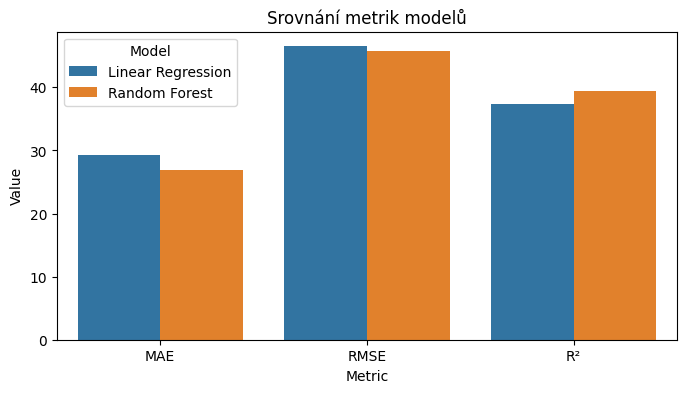

In [24]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate_model(y_val, y_pred_lr)
rf_mae, rf_rmse, rf_r2 = evaluate_model(y_val, y_pred_rf)

results = pd.DataFrame({"Linear Regression": {"MAE":  lr_mae, "RMSE": lr_rmse, "R2": lr_r2},
                        "Random Forest":     {"MAE":  rf_mae, "RMSE": rf_rmse, "R2": rf_r2}}).T
display(results.round(2))

metrics_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'] * 3,
    'Metric': ['MAE'] * 2 + ['RMSE'] * 2 + ['R²'] * 2,
    'Value': [lr_mae, rf_mae, lr_rmse, rf_rmse, lr_r2 * 100, rf_r2 * 100]})

plt.figure(figsize=(8, 4))
sns.barplot(data=metrics_df, x='Metric', y='Value', hue='Model')
plt.title('Srovnání metrik modelů')
plt.show()

MAE: RF se v průměru mýlí o 27 dní, zatímco LR o 29. <br>
RMSE: je výrazně vyšší než MAE. Oba modely dělají velké chyby u extrémních hodnot.<br>
R²: Hodnota kolem 0.40 znamená, že model vysvětluje cca 40 % variability.

I když jsou si hodnoty číselně blízké, Random Forest je lepším modelem. Oba modely však vykazují relativně vysoké chyby, což odpovídá vysoké variabilitě cílové proměnné.

In [25]:
#fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#
#sns.scatterplot(x=y_pred_lr, y=y_val - y_pred_lr, ax=axes[0], alpha=0.6)
#axes[0].axhline(0, color='red', linestyle='--')
#axes[0].set_title('Rezidua: Linear Regression')
#axes[0].set_xlabel('Predikované hodnoty')
#axes[0].set_ylabel('Rezidua (skutečné - predikované)')
#axes[0].set_xlim(-20, 300)
#axes[0].set_ylim(-280, 320)
#
#sns.scatterplot(x=y_pred_rf, y=y_val - y_pred_rf, ax=axes[1], alpha=0.6, color='tab:orange')
#axes[1].axhline(0, color='red', linestyle='--')
#axes[1].set_title('Rezidua: Random Forest')
#axes[1].set_xlabel('Predikované hodnoty')
#axes[1].set_ylabel('Rezidua (skutečné - predikované)')
#axes[1].set_xlim(-20, 300)
#axes[1].set_ylim(-280, 320)
#
#plt.tight_layout()
#plt.show()

In [26]:
#plt.figure(figsize=(12, 6))
#
#sns.scatterplot(x=y_pred_lr, y=y_val - y_pred_lr, label='Linear Regression', alpha=0.6)
#sns.scatterplot(x=y_pred_rf, y=y_val - y_pred_rf, label='Random Forest',     alpha=0.6)
#
#plt.axhline(0, color='red', linestyle='--')
#plt.axvline(0, color='red', linestyle='--')
#
#plt.xlim(-20, 300)
#plt.ylim(-280, 320)
#
#plt.title('Porovnání reziduí modelů')
#plt.xlabel('Predikované hodnoty')
#plt.ylabel('Rezidua (skutečné - predikované)')
#plt.legend()
#plt.tight_layout()
#plt.show()

In [27]:
#plt.figure(figsize=(12, 4))
#
#sns.kdeplot(y_val - y_pred_lr, label='Linear Regression', fill=True)
#sns.kdeplot(y_val - y_pred_rf, label='Random Forest', fill=True)
#plt.axvline(x=0, color='red', linestyle='--')
#plt.title('Distribuce reziduí (chyb)')
#plt.xlabel('Chyba (Skutečnost - Predikce)')
#plt.ylabel('Hustota')
#plt.legend()
#plt.show()

![images/rezidues.png](images/rezidues.png)

Analýzou reziduí (rozdílu mezi skutečnou a predikovanou hodnotou) můžeme posoudit kvalitu odhadů modelů a odhalit chyby. Ideální rezidua by měla být náhodně rozptýlená kolem nuly s konstantním rozptylem a přibližně normálně rozdělená.

Analýza reziduí ukazuje, že oba modely systematicky podhodnocují vysoké hodnoty cílové proměnné. Tento jev je pravděpodobně způsoben malým počtem extrémních pozorování v datech, podle kterých by se model mohl učit.

Rezidua lineární regrese vykazují výraznou strukturu a omezený rozsah predikovaných hodnot, včetně nerealistických záporných predikcí. To naznačuje, že model není schopen zachytit nelineární vztahy v datech.

Random Forest produkuje rezidua více koncentrovaná kolem nuly a lépe zachovává rozsah cílové proměnné, což odpovídá jeho mírně lepším hodnotám MAE a RMSE.mu ladění.





![images/error.png](images/error.png)

## Ladění modelu

Protože Random Forest byl lepší, použijeme ho na ladění. Random Forest by měl také lépe reagovat na ladění než lineární regrese.

1. **n_estimators**:
   - Určuje, kolik rozhodovacích stromů se v modelu spojí. Každý strom se trénuje na náhodném subsamplu dat a finální predikce je průměr všech stromů.
   - Vyšší hodnoty zlepšují stabilitu, přesnost, zvládnutí šumu. Nízké hodnoty mohou vést k nestabilním predikcím.
2. **max_depth**:
   - Omezuje, jak hluboko může strom růst. Bez omezení stromy rostou, dokud nejsou listy čisté.
   - Vyšší hloubka umožňuje zachytit složité vztahy, ale zvyšuje riziko overfittingu. Nižší hloubka vede k underfittingu, ale zlepšuje generalizaci.
3. **min_sample_split**:
   - Stanoví minimální počet vzorků v uzlu, aby se mohl rozdělit, brání příliš jemným splitům.
   - Vyšší hodnoty zabraňují overfittingu, ale mohou vést k underfittingu. Nižší hodnoty umožňují detailnější modely.
4. **min_samples_leaf**:
   - Určuje minimální počet vzorků v listovém uzlu a slouží k vyhlazení predikcí a omezení vlivu extrémních hodnot.
   - Vyšší hodnoty chrání před extrémními predikcemi, overfittingem a pomáhají při šikmé distribuci.
5. **max_features**:
   - Kontroluje, kolik příznaků strom vidí, a tím ovlivňuje rozmanitost stromů.
   - Menší hodnota pro větší diverzitu, která zlepší generalizaci.

In [28]:
param_dist = {'max_depth':         [10, 20, 30, 50, 75, 100],
              'max_features':      ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0, None],
              'n_estimators':      [50, 100, 200, 300, 500, 1000],
              'min_samples_leaf':  [1, 5, 10, 20, 50],
              'min_samples_split': [2, 5, 10, 20, 50]}

In [29]:
rf_random = RandomizedSearchCV(estimator           = RandomForestRegressor(random_state=RANDOM_STATE),
                               param_distributions = param_dist,
                               n_iter              = 50, 
                               cv                  = 5,
                               verbose             = 2, 
                               random_state        = RANDOM_STATE, 
                               n_jobs              = -1,
                               scoring             = 'neg_mean_absolute_error')

rf_random.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=51)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

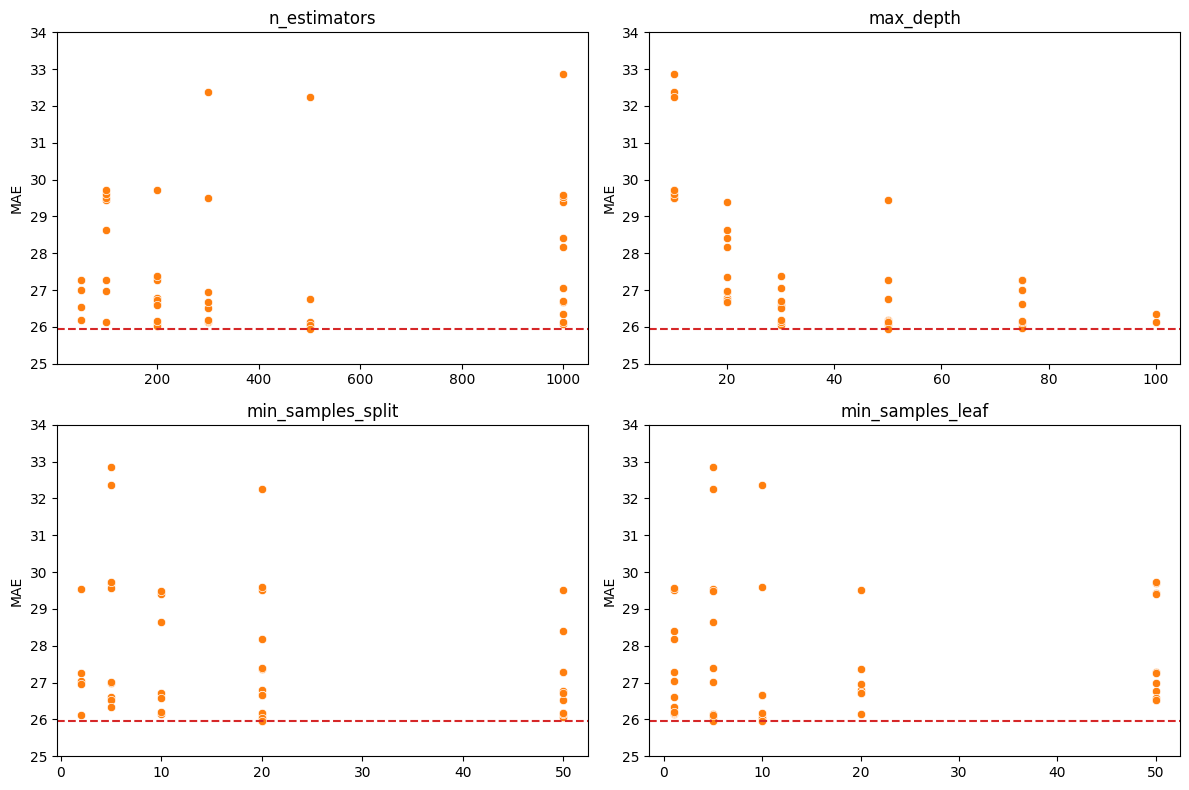

Nejlepší parametry: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.7, 'max_depth': 50}
Nejnižší MAE: 25.95


In [30]:
results = pd.DataFrame(rf_random.cv_results_)
results['MAE'] = -results['mean_test_score']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
params = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']

for ax, param in zip(axes.ravel(), params):
    sns.scatterplot(data=results, x=f'param_{param}', y='MAE', ax=ax, color='tab:orange')
    ax.set_title(param)
    ax.set_xlabel('')
    ax.set_ylim(25, 34)
    ax.axhline(results['MAE'].min(), color='tab:red', linestyle='--', label=f"Nejlepší MAE: {results['MAE'].min():.2f}")
    
plt.tight_layout()
plt.show()

print(f"Nejlepší parametry: {rf_random.best_params_}")
print(f"Nejnižší MAE: {results['MAE'].min():.2f}")

1. **n_estimators**:
   - S rostoucím počtem stromů MAE mírně klesá a stabilizuje se, což potvrzuje očekávání, že více stromů průměruje šum a outliers v datech.
2. **max_depth**:
   - Vyšší hodnoty dávají lepší výsledky než nízké, protože dataset má složité interakce (např. věk × hobby). Příliš nízká hloubka vede k underfittingu (MAE nad 29).
3. **min_sample_split**:
   - Příliš nízké hodnoty vedly k mírnému overfittingu, zatímco příliš vysoké (50) už model omezovaly v učení důležitých rozdílů v datech.
4. **min_samples_leaf**:
   - Příliš vysoké hodnoty zvyšují chybu, protože model příliš "vyhlazuje" a ztrácí detaily. Nejlepší hodnota 10 brání modelu, aby se učil šum z jednotlivých záznamů, ale stále mu dovoluje vidět specifika menších skupin obyvatel.
5. **max_features**:
   - Hodnota 0.7 zvítězila nad 'sqrt' nebo 'log2'. To naznačuje, že naše příznaky jsou natolik unikátní, že stromy potřebují vidět většinu z nich (70%) v každém uzlu, aby udělaly správné rozhodnutí.

Celkem to znamená, že model preferuje dostatek stromů (500 pro stabilitu), střední regularizaci (split/leaf 20/10 zabraňuje přeučení na malých skupinách), velkou diverzitu (max_features=0.7) a omezenou hloubku (50 místo None, což také brání overfittingu). Nejlepší kombinace stlačila MAE na 25.95. V porovnání s výchozím modelem (MAE cca 26.86) jsme laděním získali zlepšení o téměř 1 den.

## Chování výsledného modelu

Teď se podíváme, jak si náš nejlepší model poradí s daty, které neviděl.

In [31]:
best_model = rf_random.best_estimator_
y_test_pred = best_model.predict(x_test)

final_mae = mean_absolute_error(y_test, y_test_pred)

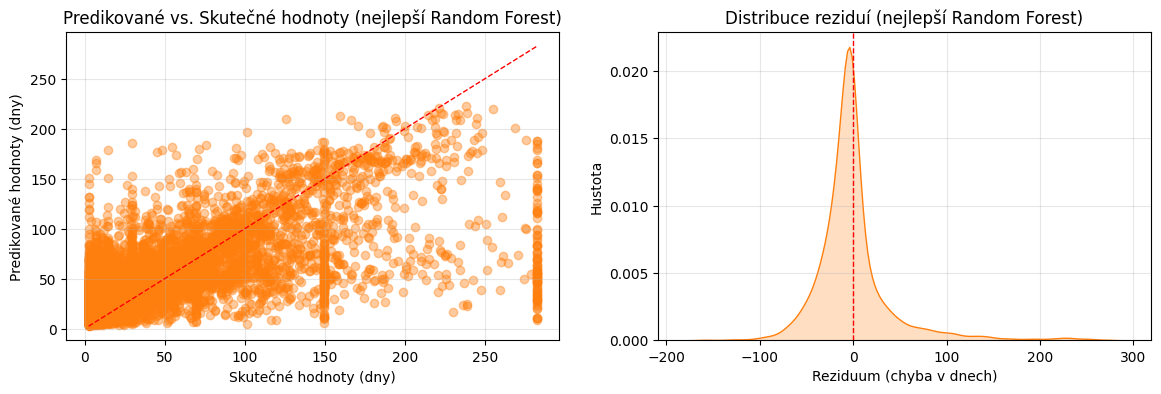

Finální MAE na testovacích datech: 25.21


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_test, y_test_pred, alpha=0.4, color='tab:orange')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=1)
axes[0].set_title('Predikované vs. Skutečné hodnoty (nejlepší Random Forest)')
axes[0].set_xlabel('Skutečné hodnoty (dny)')
axes[0].set_ylabel('Predikované hodnoty (dny)')
axes[0].grid(True, alpha=0.3)

sns.kdeplot(y_test - y_test_pred, fill=True, color='tab:orange')
#sns.histplot(y_test - y_test_pred, kde=True, color='tab:orange', stat='density', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Distribuce reziduí (nejlepší Random Forest)')
axes[1].set_xlabel('Reziduum (chyba v dnech)')
axes[1].set_ylabel('Hustota')
axes[1].grid(True, alpha=0.3)

plt.show()

print(f"Finální MAE na testovacích datech: {final_mae:.2f}")

První graf zobrazuje shodu mezi skutečnými daty a odhady modelu. Červená přerušovaná čára představuje ideální predikci. Vidíme, že model se poměrně dobře drží trendu u hodnot do cca 100 dní, kde je hustota bodů nejvyšší. U vysokých hodnot má však model tendenci k podhodnocování. To je způsobeno malým počtem tréninkových příkladů pro tyto vysoce aktivní skupiny.

Graf distribuce chyb ukazuje, že většina predikcí modelu se nachází v blízkosti nuly, což je žádoucí stav. Křivka má však dlouhý pravostranný ohon. To znovu potvrzuje, že u určité části populace model podhodnocuje jejich aktivitu. Špičatost distribuce kolem nuly však dokazuje, že ladění hyperparametrů pomohlo modelu dosáhnout vysoké přesnosti pro většinové spektrum populace.

Finální model dosáhl na testovacích datech hodnoty MAE 25.21, což představuje zlepšení oproti základním modelům. Další zlepšení by bylo možné například transformací cílové proměnné (např. log-transformací) nebo použitím modelů optimalizovaných pro šikmé rozdělení.

## Důležitost příznaků

Budeme analyzovat důležitost jednotlivých příznaků a jejich vztah k cílové proměnné. Pomocí nich můžeme ověřit, zda se model skutečně učí nejpodstatnější vztahy v datech.

### Modelově nezávislá metoda

Pro stanovení důležitosti příznaků použijeme dvě metody: Spearmanova korelace a vzájemná informace.<br>
Obě metody jsou nezávislé na modelu a ukazují, jak moc každý příznak souvisí s 'value'.<br>
Spearmanova korelace je vhodná pro zachycení monotónních vztahů a je robustní vůči odlehlým hodnotám a nelinearitám.<br>
Vzájemná informace umožňuje identifikovat i obecné nelineární závislosti mezi vstupními příznaky a cílovou proměnnou, které nemusí být korelační povahy.

In [33]:
correlations = x.corrwith(y, method='spearman').sort_values(ascending=False)

co_top    = correlations.head(10)
co_bottom = correlations.tail(10)
separator = pd.Series([np.nan], index=['-----------------------------------------------------------------'])
corrs     = pd.concat([co_top, separator, co_bottom])

co_colors = (['tab:blue'] * len(co_top) + ['white'] + ['tab:green'] * len(co_bottom))

In [34]:
discrete_features = [True] * x.shape[1]
mi_scores = mutual_info_regression(x, y, discrete_features=discrete_features, random_state=RANDOM_STATE)

mi_series = pd.Series(mi_scores, name="MI Scores", index=x.columns)
mi_series = mi_series.sort_values(ascending=False)

mi_top    = mi_series.head(10)
mi_bottom = mi_series.tail(10)
mi_gain   = pd.concat([mi_top, separator, mi_bottom])

mi_colors = (['tab:green'] * len(mi_top) + ['white'] + ['tab:blue'] * len(mi_bottom))

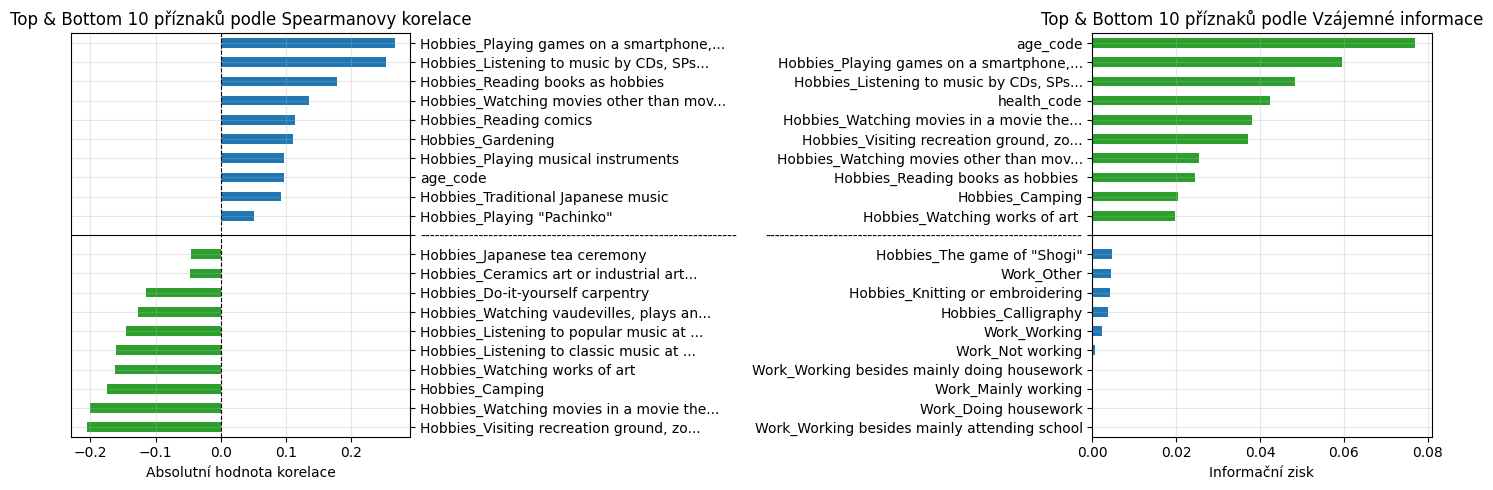

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corrs.plot(kind='barh', color=co_colors, ax=axes[0])
axes[0].invert_yaxis()
axes[0].yaxis.set_label_position("right")
axes[0].yaxis.tick_right()
axes[0].set_title('Top & Bottom 10 příznaků podle Spearmanovy korelace')
axes[0].set_xlabel('Absolutní hodnota korelace')
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].axhline(10, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

mi_gain.plot(kind='barh', color=mi_colors, ax=axes[1])
axes[1].invert_yaxis()
axes[1].axhline(10, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Top & Bottom 10 příznaků podle Vzájemné informace')
axes[1].set_xlabel('Informační zisk')

plt.tight_layout()
plt.show()

Porovnání obou metod ukazuje konzistentní výsledky. Mezi nejvýznamnější příznaky se opakovaně řadí digitální a domácí volnočasové aktivity, zejména hraní her, poslech hudby a sledování filmů. Tyto příznaky vykazují jak relativně vyšší korelaci, tak vyšší hodnoty vzájemné informace. Tyto aktivity jsou dostupné každý den, což model i statistika jasně vidí.

V korelaci je věk až na 8. místě, ale ve vzájemné informaci je věk na 1. místě, což poukazuje na to, že věk nemá s aktivitou přímočarý vztah. Při analýze datasetu jsme zjistili, že aktivita je vysoká u mladých, klesá ve středním věku a znovu roste u seniorů. Korelace takový vztah neumí dobře zachytit, ale vzájemná informace ano, a proto hodnotí věk jako informačně nejbohatší příznak. Zdravotní stav má také významný vliv ve vzájemné informaci, pravděpodobně kvůli volnému času u horšího zdraví.

Na opačném konci jsou příležitostní aktivity (kempink, zoo, kina, koncerty), mají slabý nebo záporný vztah k vysokému počtu dní, což odpovídá jejich nízké frekvenci. 

V tabulce vzájemné informace vidíme, že příznaky související s prací (Work_...) jsou úplně vespod. To potvrzuje náš dřívější závěr: samotný fakt, že někdo pracuje, modelu neřekne o frekvenci koníčků skoro nic. Jedná se spíše o sekundární faktor, který je již částečně obsažen v informaci o věku a typu záliby.

Typ hobby vysvětluje největší část variability, zatímco věk a zdraví mají menší doplňující roli a pohlaví a rodinný stav jen málo. Tudíž nemáme příznak, který by dominantně vysvětloval výstupní proměnnou, a poukazuje na komplexní charakter lidského volnočasového chování a podporuje použití modelů schopných kombinovat více slabších signálů.signálů.

### Modelově závislá metoda

Po analýze nezávislé na modelu přecházíme ke globální interpretaci finálního modelu. Tato metoda nám ukazuje, jakou důležitost přikládá model jednotlivým příznakům při tvorbě svých rozhodovacích stromů. Využíváme metodu Mean Decrease in Impurity (průměrného snížení nečistoty), která měří, jak moc se v průměru sníží chyba modelu při použití daného příznaku pro rozdělení uzlu. Čím větší je toto snížení, tím větší vliv má příznak na predikci modelu. Tato analýza nám potvrdí, zda se model naučil vztahy, které jsme identifikovali dříve, a jak efektivně kombinuje demografické údaje se zálibami.i.

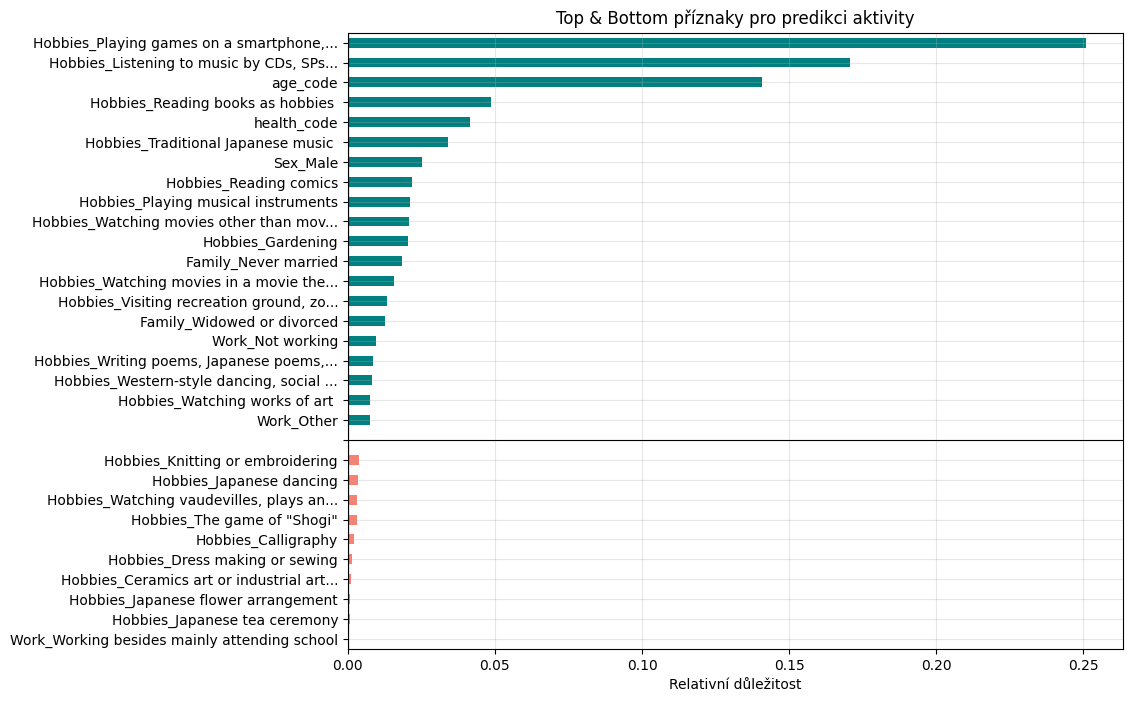

In [36]:
importances = pd.Series(best_model.feature_importances_, index=x_train.columns).sort_values(ascending=False)

im_top    = importances.head(20)
im_bottom = importances.tail(10)
separator = pd.Series([np.nan], index=[' '])
important = pd.concat([im_top, separator, im_bottom])

im_colors = (['teal'] * len(im_top) + ['white'] + ['salmon'] * len(im_bottom))

plt.figure(figsize=(10, 8))

ax = important.plot(kind='barh', color=im_colors)
plt.title('Top & Bottom příznaky pro predikci aktivity')
plt.xlabel('Relativní důležitost')
ax.invert_yaxis()
plt.axvline(0,  color='black', linestyle='-', linewidth=0.8)
plt.axhline(20, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.show()

Model se primárně opírá o informace o typu volnočasových aktivit, což odpovídá předchozím zjištěním z korelace i vzájemné informace. Tyto aktivity jsou časté a dobře rozlišují mezi jednotlivými úrovněmi cílové proměnné. Hraní her a poslech hudby tvoří dohromady přes 42% veškeré rozhodovací síly modelu. To je velmi silný signál.

Věk (nejdůležitější "nedigitální") a zdravotní stav představují důležité kontextové faktory, které ovlivňují jak množství, tak typ volnočasových aktivit. Model je využívá k jemnějšímu rozlišení mezi jednotlivými skupinami respondentů. To, že se umístil tak vysoko, potvrzuje, že Random Forest dokázal využít nelineární vztah věku a zdravotního stavu k aktivitě.

Pohlaví, rodinný stav a pracovní status, tyto příznaky samy o sobě nepřinášejí modelu výraznou predikční sílu a jejich vliv je spíše nepřímý, případně zprostředkovaný jinými proměnnými. Model nám tím říká, že mnohem důležitější je, co děláte, než kdo jste.

## Závěr

Analyzovali a modelovali jsme agregovaný dataset zaměřený na frekvenci volnočasových aktivit a jejich vztah k demografickým skupinám v Japonsku. Bylo ukázáno, že cílová proměnná má výrazně šikmou distribuci s přítomností extrémních hodnot, které však představují reálné chování části populace.

Porovnáním modelů jsme zjistili, že pro komplexní sociologická data s nelineárními vztahy je vhodnější složitější model Random Forest, který po ladění hyperparametrů dosáhl průměrné absolutní chyby 25,21 dní.

Celkově analýza ukázala, že volnočasové chování je v japonské společnosti poměrně stabilní napříč demografickými skupinami a nejsilnějším prediktorem je typ záliby, zejména u digitálních a domácích aktivit (hry, hudba), které lze provozovat denně, než příležitostní aktivity (kempování, návštěva zoo či kin). Metoda vzájemné informace dále odhalila zásadní roli věku a zdravotního stavu, jehož vlivy na volný čas jsou nelineární a pro model klíčové. Práce, pohlaví a rodinný stav mají na predikci jen minimální přímý dopad.

Ačkoliv model vykazuje určité limity u predikce extrémně vysokých hodnot způsobené nevyvážeností datasetu, poskytuje stabilní výsledky a cenný vhled do struktury volnočasového chování populace.